Sepsis Survival & Risk Prediction Platform

Sepsis is a life-threatening medical emergency.Hospitals need a system that can:
● Predict survival probability early
● Identify high-risk patients
● Assist ICU decision-making
● Reduce mortality rates

Build an AI-powered Sepsis Survival Assessment Platform that:
● Classifies patient survival risk (High / Medium / Low)
● Predicts probability of death
Provides explainable insights
● Supports hospital decision-making systems

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filepath=r"C:\Users\laksh\Projects\Final project Sepsis Survival & Risk Prediction Platform\data\s41598-020-73558-3_sepsis_survival_dataset\s41598-020-73558-3_sepsis_survival_primary_cohort.csv"
df = pd.read_csv(filepath)
df.head()

,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1


In [3]:
# Basic info about the dataset
df.shape

(110204, 4)

In [4]:
# Column info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110204 entries, 0 to 110203
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   age_years                      110204 non-null  int64
 1   sex_0male_1female              110204 non-null  int64
 2   episode_number                 110204 non-null  int64
 3   hospital_outcome_1alive_0dead  110204 non-null  int64
dtypes: int64(4)
memory usage: 3.4 MB


In [5]:
#summary
df.describe()


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
count,110204.000000,110204.000000,110204.000000,110204.000000
mean,62.735255,0.473948,1.349379,0.926455
std,24.126806,0.499323,0.751799,0.261031
min,0.000000,0.000000,1.000000,0.000000
25%,51.000000,0.000000,1.000000,1.000000
50%,68.000000,0.000000,1.000000,1.000000
75%,81.000000,1.000000,1.000000,1.000000
max,100.000000,1.000000,5.000000,1.000000


In [6]:
#check missing values
missing_values = df.isnull().sum()
missing_values

age_years                        0
sex_0male_1female                0
episode_number                   0
hospital_outcome_1alive_0dead    0
dtype: int64

In [7]:
# Column names are long so renaming them 
df = df.rename(columns={
    "age_years": "age",
    "sex_0male_1female": "sex",
    "episode_number": "episode",
    "hospital_outcome_1alive_0dead": "outcome"
})

In [8]:
df.head()


,age,sex,episode,outcome
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1


In [9]:
# Convert Categorical Meaningful Values
df['sex'] = df['sex'].map({0: 'male', 1: 'female'})


In [10]:
df['sex'].value_counts()

sex
male      57973
female    52231
Name: count, dtype: int64

In [11]:
df['outcome'] = df['outcome'].map({0: 'dead',   1: 'alive'})

In [12]:

df['outcome'].value_counts()

outcome
alive    102099
dead       8105
Name: count, dtype: int64

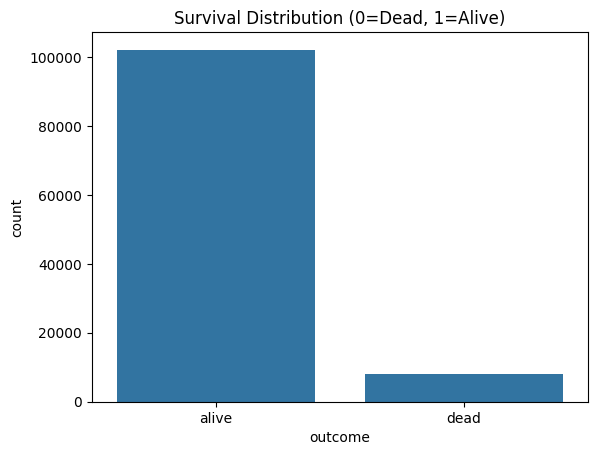

In [13]:
#plot survival outcome distribution

sns.countplot(x='outcome', data=df)
plt.title("Survival Distribution (0=Dead, 1=Alive)")
plt.show()

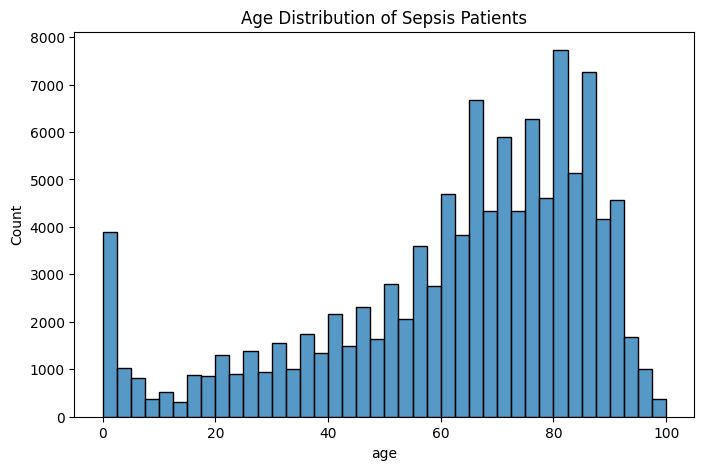

In [14]:
#Check Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=40)
plt.title("Age Distribution of Sepsis Patients")
plt.show()

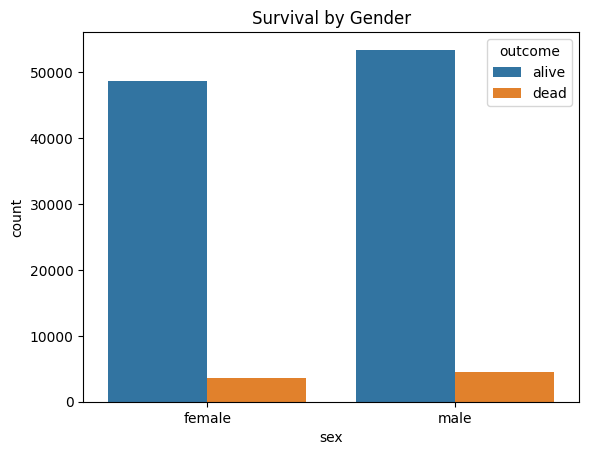

In [15]:
#Check Gender Distribution
sns.countplot(x='sex', hue='outcome', data=df)
plt.title("Survival by Gender")
plt.show()

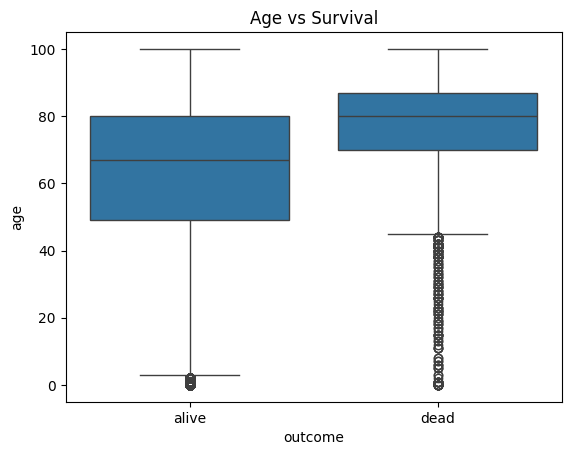

In [16]:
# survival by age group
sns.boxplot(x='outcome', y='age', data=df)
plt.title("Age vs Survival")
plt.show()

In [17]:
df.to_csv("../data/sepsis_clean.csv", index=False)